In [3]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
from scipy.stats import pearsonr, zscore, kurtosis, shapiro
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression


df = pd.read_csv("data/advertising_and_sales.csv", index_col="id")

display(Markdown("### Descripción Estadística"))
display(df.describe())

display(Markdown("### Vista Previa del Histórico (Primeros 10 Registros)"))
display(df.head(10))

### Descripción Estadística

,tv,radio,social_media,sales
count,4500.000000,4500.000000,4500.000000,4500.000000
mean,54903.547138,18321.505844,3335.742613,96000.371107
std,30135.928474,11628.678497,2211.899475,50418.221025
min,33.970000,0.440000,0.030000,10120.020000
25%,30478.517500,9286.802500,1539.770000,53965.212500
50%,52026.315000,16297.640000,3070.610000,90598.950000
75%,75761.262500,25691.567500,4812.652500,130934.470000
max,150940.950000,71122.910000,13981.660000,237705.490000


### Vista Previa del Histórico (Primeros 10 Registros)

,tv,radio,social_media,influencer,sales
id,,,,,
0,11124.31,6906.88,2907.98,Mega,34660.95
1,102.79,12676.45,2409.57,Mega,15456.04
2,45774.58,14914.53,2913.41,Mega,63816.23
3,65232.46,32016.26,6922.30,Mega,189884.07
4,11376.10,5490.95,1406.00,Micro,22198.20
5,40583.98,11999.30,1027.16,Mega,67744.72
6,54064.46,14125.79,4273.60,Micro,91904.10
7,30221.43,14291.12,2289.85,Nano,35076.75
8,60356.57,28263.00,7130.12,Macro,101202.65


#### Análisis Descriptivo: descartar y adoptar factores
Como base analítica, a continuación se realiza una visuliazación de análisis multivariable (relacionando valores continuos y categorías), de manera que se puedan extraer resultados a primera vista:

- Hay un claro incremento monetario conforme aumenta el presupuesto en TV y Radio
- Hay una concentración mayor de valores con cierta varianza en la variable TV
- La jerarquía en la variable influencer no influyen en lo absoluto en las ventas

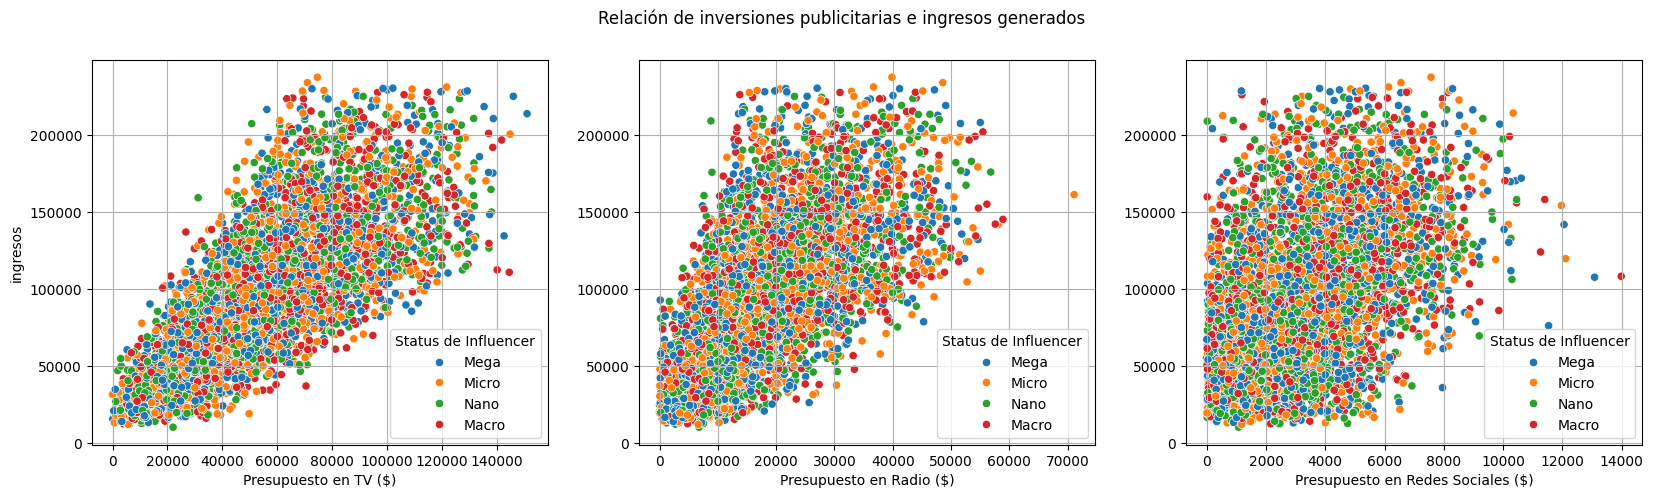

In [4]:
fig, ax = plt.subplots(1,3, figsize=(20,5))

sns.scatterplot(data=df, x="tv", y="sales", hue="influencer", ax=ax[0])
ax[0].grid("on")
ax[0].set_xlabel("Presupuesto en TV ($)")
ax[0].set_ylabel("ingresos")
ax[0].legend(title="Status de Influencer")

sns.scatterplot(data=df, x="radio", y="sales", hue="influencer", ax=ax[1])
ax[1].grid("on")
ax[1].set_xlabel("Presupuesto en Radio ($)")
ax[1].set_ylabel("")
ax[1].legend(title="Status de Influencer")

sns.scatterplot(data=df, x="social_media", y="sales", hue="influencer", ax=ax[2])
ax[2].grid("on")
ax[2].set_xlabel("Presupuesto en Redes Sociales ($)")
ax[2].set_ylabel("")
ax[2].legend(title="Status de Influencer")

fig.suptitle("Relación de inversiones publicitarias e ingresos generados")
plt.subplots_adjust(wspace=0.2)
plt.show()

#### Análisis Exploratorio de Datos: determinar patrones e hipótesis

Seguidamente se explorará el comportamiento de los datos donde el objetivo es descubrir patrones, relaciones y estructuras que guíen la implementación de un modelo particular como solución. En un caso de regresión lineal con resultados fiables, se deben cumplir los siguientes supuestos fundamentales:

**Linealidad**: La relación entre la variable independiente (X) y la variable dependiente (Y) debe ser lineal. Esto significa que el cambio en (Y) por cada unidad de cambio en (X) es constante.

**Normalidad de los residuos**: Para propósitos de inferencia (pruebas de hipótesis y cálculos de intervalos de confianza), los residuos del modelo deben seguir una distribución normal con media cero.

**Ausencia de Outliers**: Los datos no deben contener valores extremos influyentes que distorsionen significativamente la pendiente de la línea de regresión.

In [17]:
corr_tv, _ = pearsonr(df["tv"], df["sales"])
corr_radio, _ = pearsonr(df["radio"], df["sales"])

df_zscore = df.loc[:, ["tv","radio"]]

df_zscore["tv_zscore"] = abs(zscore(df["tv"]))
df_zscore["radio_zscore"] = abs(zscore(df["radio"]))

outliers_tv = df_zscore.loc[df_zscore["tv_zscore"] > 3, "tv_zscore"].shape[0]
outliers_radio = df_zscore.loc[df_zscore["radio_zscore"] > 3, "radio_zscore"].shape[0]

curtosis_tv = kurtosis(df["tv"])
curtosis_radio = kurtosis(df["radio"])

data = {
   "TV": [round(corr_tv,2), outliers_tv, round(curtosis_tv,1)],
   "Radio": [round(corr_radio,2), outliers_radio, round(curtosis_radio,1)]
}

df_measures  = pd.DataFrame(data, index=["correlacion (sales)", "outliers", "curtosis"])

display(Markdown("#### Métricas Estadísticas"))
display(df_measures)

#### Métricas Estadísticas

,TV,Radio
correlacion (sales),0.77,0.65
outliers,2.00,16.00
curtosis,-0.50,0.00


#### Linear Regression: modelado segmentado por mayor rentabilidad
A partir de las pruebas estadísticas ejecutadas en la fase de análisis exploratorio de datos (EDA), se identificó que la inversión en el canal de Televisión (TV) presenta la relación lineal más robusta y significativa con respecto al volumen de Ventas (Sales). Por este motivo, se seleccionaron estas dimensiones para el desarrollo del modelo de regresión lineal, configurando la inversión en TV como la variable independiente (X) y el nivel de Sales como la variable dependiente u objetivo (Y).

In [16]:
X_train = df["tv"].values.reshape((-1, 1))
y_train = df["sales"]

model_frontier = LinearRegression()
model_frontier.fit(X_train, y_train)

y_pred_train = model_frontier.predict(X_train)

r2 = r2_score(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

residuals = y_train - y_pred_train
stat, p_val = shapiro(residuals)
norm_residuals = p_val > 0.05

display(Markdown("#### --- RESULTADOS DE VALIDACIÓN DEL MODELO (EFICIENTE) ---"))
print(f"Coeficiente de Determinación (R²): {round(r2, 4)}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${round(rmse, 2)}")
print(f"Normalidad de Residuos (Shapiro-Wilk): p-valor = {p_val:.4e} -> {'PASÓ' if norm_residuals else 'FALLÓ'}")
print("-" * 70)
print(f"Interpretación: El modelo explica el {round(r2*100, 2)}% de la variación en ventas.")
if r2 > 0.80 and norm_residuals:
    print("Estado: MODELO VALIDADO PARA PRODUCCIÓN (DASHBOARD).")
elif r2 > 0.80 and not norm_residuals:
    print("Estado: REVISAR SUPUESTOS - Alta precisión pero residuos no normales.")
else:
    print("Estado: REVISAR SEGMENTACIÓN - Precisión por debajo del umbral objetivo.")

#### --- RESULTADOS DE VALIDACIÓN DEL MODELO (EFICIENTE) ---

Coeficiente de Determinación (R²): 0.5977
Raíz del Error Cuadrático Medio (RMSE): $31973.73
Normalidad de Residuos (Shapiro-Wilk): p-valor = 6.0772e-25 -> FALLÓ
----------------------------------------------------------------------
Interpretación: El modelo explica el 59.77% de la variación en ventas.
Estado: REVISAR SEGMENTACIÓN - Precisión por debajo del umbral objetivo.


#### Herramienta interactiva de optimización estratégica basado en la frontera de eficiencia presupuestaria

In [ ]:
def get_elasticities(data):
    df_log = np.log(data[["tv", "radio", "social_media", "sales"]] + 1)
    model = LinearRegression()
    model.fit(df_log[["tv", "radio", "social_media"]], df_log["sales"])
    return dict(zip(["TV", "Radio", "Social Media"], model.coef_))

elasticities = get_elasticities(df)
mean_margin = df["sales"].mean() - (df["tv"].mean() + df["radio"].mean() + df["social_media"].mean())

app = dash.Dash(__name__)

app.layout = html.Div(id="body", className="e2_body", children=[
    html.H1("Estrategia de Inversión: del volumen a la rentabilidad", className="e2_title"),

    html.Div(className="e2_div_stats", children=[
        html.Div([html.H3("Margen Neto Promedio"), html.P(f"${round(mean_margin, 2)}", style={"font-weight":"bold","font-size":"1.2em"})], className="e2_stats"),
        html.Div([html.H3("Elasticidad TV (Dominancia)"), html.P(f"{round(elasticities["TV"], 2)}", style={"font-weight":"bold","font-size":"1.2em"})], className="e2_stats"),
        html.Div([html.H3("Elasticidad Radio (Oportunidad)"), html.P(f"{round(elasticities["Radio"], 2)}", style={"font-weight":"bold","font-size":"1.2em"})], className="e2_stats"),
    ]),

    html.Div(id="dashboard", className="e2_dashboard", children=[
         html.Div(className="e2_column_1", children=[
             html.Div(className="e2_div_graphs", children=[
                 dcc.Graph(id="graph-pie", className="e2_graphs", figure={}),
                 dcc.Graph(id="graph-bar", className="e2_graphs", figure={})
             ]),

             html.Div(className="e2_div_slider", children=[
                html.Label("Simulador de Rebalanceo: Mover presupuesto de TV a Radio (%)", className="e2_label"),
                dcc.Slider(
                    id="rebalance-slider",
                    min=0, max=30, step=5, value=0,
                    marks={i: {"label": f"{i}%", "style": {"color": "white"}} for i in range(0, 31, 5)}
                )
            ])
        ]),

        html.Div(className="e2_column_2", children=[
           dcc.Graph(id="graph-scatter"),
           html.Div(id="text-resolution", className="e2_text_resolution")
        ])
    ])
])


@app.callback(
    [Output(component_id="graph-pie",component_property="figure"),
    Output(component_id="graph-bar",component_property="figure"),
    Output(component_id="graph-scatter",component_property="figure"),
    Output(component_id="text-resolution",component_property="children")],
   [Input(component_id="rebalance-slider",component_property="value")]
)

def update_strategy(rebalance_pct):
    cost_tv_orig = df["tv"].mean()
    money_change = cost_tv_orig * (rebalance_pct / 100)

    piechart = go.Figure(data=[go.Pie(labels=["TV", "Radio", "RRSS"],
                               values=[df["tv"].mean(), df["radio"].mean(), df["social_media"].mean()])])
    piechart.update_layout(title="Distribución Actual del Gasto")

    barchart = go.Figure([go.Bar(x=list(elasticities.keys()), y=list(elasticities.values()), marker_color="indigo")])
    barchart.update_layout(title="Elasticidad: Sensibilidad de Ventas al +1% Gasto", yaxis_title="Impacto % en Ventas")

    df["ROI"] = (df["sales"] - df["tv"]) / df["tv"]
    df_efficient = df[df["ROI"] >= df["ROI"].quantile(0.12)]

    scatter = go.Figure()
    scatter.add_trace(go.Scatter(x=df["tv"], y=df["sales"], mode="markers", name="Campaña Estándar", opacity=0.4))
    scatter.add_trace(go.Scatter(x=df_efficient["tv"], y=df_efficient["sales"], mode="markers", name="Frontera de Eficiencia", marker=dict(color="green", size=8)))
    scatter.update_layout(title="Identificación de la Frontera de Eficiencia", xaxis_title="Gasto TV", yaxis_title="Ventas")

    sales_est = df["sales"].mean() * (1 + (rebalance_pct/100 * elasticities["Radio"]))
    text = [
        html.H4("Resolución Estratégica:"),
        html.P(f"Al rebalancear un {rebalance_pct}% de TV hacia Radio, estás moviendo ${round(money_change, 2)} a un canal con mayor retorno marginal."),
        html.P(f"Estimación: Las ventas podrían optimizarse un {round(rebalance_pct * elasticities["Radio"], 2)}% manteniendo el presupuesto constante.")
    ]

    return piechart, barchart, scatter, text

if __name__ == "__main__":
    app.run(debug=False)